# Escalonamento Conjunto de Capacidade do Modelo e Volume de Dados em Redes Neurais Profundas

---

**Pergunta**


Como o desempenho de um modelo de classificação de imagens varia conjuntamente em função da capacidade do modelo (número de parâmetros) e do volume de dados de treinamento disponível, e existe uma relação de troca (trade-off) entre investir em mais dados versus investir em um modelo de maior capacidade?

Escalonamento Conjunto a primeira parte da pergunta busca entender o comportamento do desempenho (ou do erro de generalização) quando variamos, simultaneamente, a capacidade representacional da rede neural e a quantidade de exemplos disponíveis.


Análise de Custo-Benefício (Trade-off) a segunda parte investiga a fronteira de eficiência do problema, questionando se há um cenário onde alocar recursos para ampliar o dataset é estritamente mais vantajoso do que aumentar a arquitetura do modelo, ou vice-versa.

A hipótese derivada é que modelos de menor capacidade atingem seu ponto de saturação com
volumes de dados menores (a capacidade representacional se torna o fator limitante antes que os
dados se esgotem), enquanto modelos de maior capacidade continuam se beneficiando de mais
dados por mais tempo, mas exigem volumes maiores para que essa capacidade extra se traduza
em ganho real de desempenho

Como restrição metodológica rígida para isolar essas variáveis, o treinamento será
executado integralmente do zero (from scratch). O uso de pesos pré-treinados (transfer learning)
introduziria um viés de transferência de conhecimento externo (knowledge transfer), atuando
como uma variável de confusão (confounder) que mascararia o impacto real da escassez de
dados nos pontos iniciais da curva e invalidaria o ajuste da forma funcional proposta na
literatura.

### Exemplo - Superfície de Erro" (Error Landscape) que o autore Rosenfeld (2020) descreve.

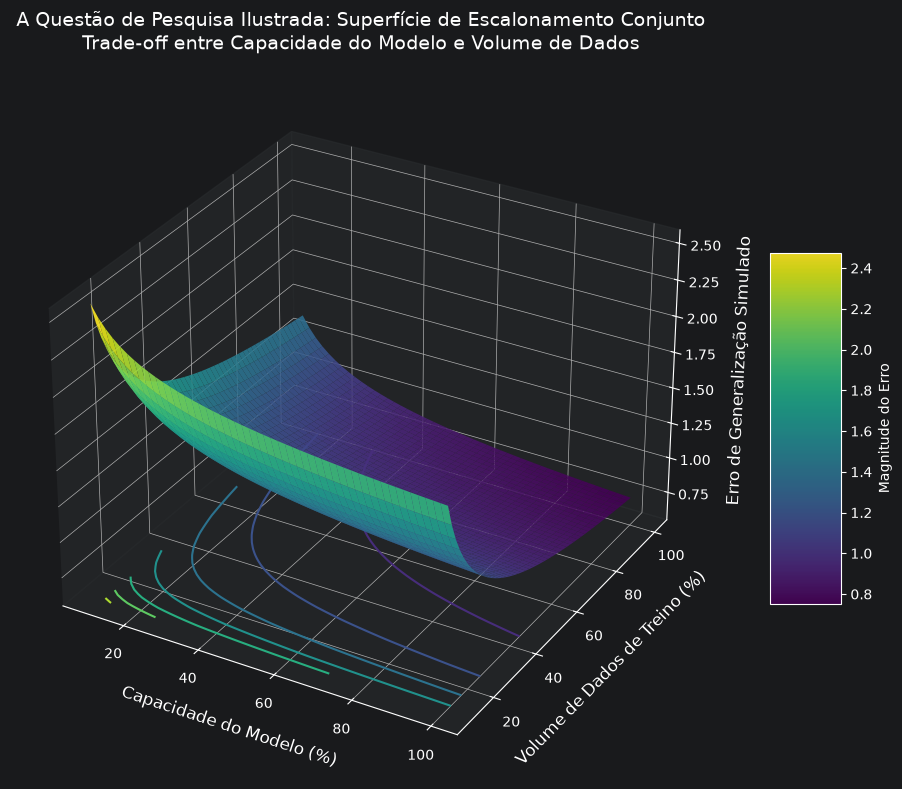

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

tamanho_modelo = np.linspace(0.1, 1.0, 50)
volume_dados = np.linspace(0.1, 1.0, 50)
M, D = np.meshgrid(tamanho_modelo, volume_dados)
termo_modelo = 0.3 * (1 / (M ** 0.5))
termo_dados = 0.4 * (1 / (D ** 0.6))
erro_irredutivel = 0.05
erro_total = termo_modelo + termo_dados + erro_irredutivel
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(M * 100, D * 100, erro_total, cmap='viridis', edgecolor='none', alpha=0.9)

ax.contour(M * 100, D * 100, erro_total, zdir='z', offset=np.min(erro_total) - 0.2, cmap='viridis')
ax.set_title('A Questão de Pesquisa Ilustrada: Superfície de Escalonamento Conjunto\nTrade-off entre Capacidade do Modelo e Volume de Dados', fontsize=14, pad=20)
ax.set_xlabel('\nCapacidade do Modelo (%)', fontsize=12)
ax.set_ylabel('\nVolume de Dados de Treino (%)', fontsize=12)
ax.set_zlabel('\nErro de Generalização Simulado', fontsize=12)
ax.set_zlim(np.min(erro_total) - 0.2, np.max(erro_total))
fig.colorbar(surf, shrink=0.5, aspect=5, label='Magnitude do Erro')

plt.tight_layout()
plt.show()

* o erro (eixo vertical Z, a altura do gráfico) só atinge o seu valor mais baixo quando ambos (Volume de Dados e Capacidade do Modelo) estão próximos de 100%.
* Note que quando você sai de 10% para 40%, o erro cai drasticamente. Mas quando você sai de 70% para 100%, a queda do erro é bem menor. É aqui que você se pergunta: "A partir de que ponto o ganho se torna marginal?
* As linhas desenhadas no "chão" do gráfico (curvas de contorno). representam níveis de erros iguais (iso-erro). Elas ilustram perfeitamente a pergunta: "Se eu quiser chegar a um erro de 0.5, é mais barato eu usar 100% dos dados com 40% do modelo, ou 100% do modelo com apenas 50% dos dados?" Isso transforma aquele parágrafo teórico complexo da sua introdução (o framework de Kaplan e Rosenfeld) em uma visualização imediata do problema real que você está tentando otimizar!

## **Metodologia**

---

**Dataset**


O projeto utiliza como base de dados o PlantVillage, um repositório público amplamente reconhecido na literatura de visão computacional aplicada à agricultura, disponível no GitHub sob o diretório ai-agriculture-circuits-and-systems/plant_village. Em sua totalidade, este conjunto original abriga aproximadamente 54.306 imagens coloridas. Essas imagens estão distribuídas ao longo de 38 classes distintas, englobando diferentes espécies de plantas e variadas condições de doenças foliares.

Processos aplicados ao conjunto de dados para garantir um ambiente não arbitrario:

```
* O experimento foi isolado em um subconjunto focado exclusivamente na cultura do Tomate.
* Foram selecionadas exatamente 10 classes desta cultura.
* Cada classe contém rigorosamente 1.000 imagens, totalizando uma base controlada de 10.000 imagens.
* Esta composição garante um dataset perfeitamente balanceado por construção. Isso é fundamental porque qualquer desbalanceamento residual atuaria como uma
  variável de confusão (confounder), misturando o efeito isolado de "escassez de dados" com o viés de "classes sub-representadas".
```

**Particionamento de Dados e Amostragem**

A divisão do conjunto de dados obedece a um padrão fundamentado na Teoria do Aprendizado Estatístico, projetado para controlar a variância da estimativa do erro. A proporção de divisão estabelecida é fixa em 70/15/15:


```
* Um pool de 7.000 imagens que serve como base para a amostragem estratificada e aninhada dos volumes de dados (de 1% a 100%).
* Um conjunto de 1.500 imagens reservado para a Fase 2 do projeto, utilizado estritamente para treinar e avaliar modelos em porcentagens intermediárias
  para validar a curva estimada pelo meta-modelo.
* Um conjunto de 1.500 imagens que permanece imutável e intocado durante todo o processo. Ele é usado para a avaliação final e fornece um intervalo de
  confiança robusto o suficiente para atestar matematicamente o critério de saturação.
```

In [ ]:
# pipeline de tratamento de split de dados.
!python src/split_dataset.py

---

**Arquitetura: ResNet-18 com Escalonamento de Largura**

A arquitetura-base será a ResNet-18, rede residual de 18 camadas cujas conexões de salto (skip
connections) resolvem o problema de degradação observado em redes muito profundas treinadas
diretamente por descida de gradiente.

```
Referência: He, Zhang, Ren & Sun (2016) — Deep Residual Learning for Image Recognition, CVPR.
```


Essas conexões residuais produzem superfícies de perda (loss landscapes) comprovadamente mais
suaves e com menos mínimos locais ruins, o que facilita a convergência mesmo em regimes de
poucos dados e treinamento ruidoso — propriedade especialmente relevante neste estudo, que
testa o modelo justamente nos extremos de baixo volume de dados (1% e 2%).

````Referência: Li, Xu, Taylor, Studer & Goldstein (2018) — Visualizing the Loss Landscape of Neural Nets, NeurIPS````

Para isolar perfeitamente o impacto do volume de dados e do tamanho do modelo no erro de generalização, implementamos um controle estrito de variáveis através do script src/init_weights.py. Este componente gera e congela os pesos iniciais de cada uma das 4 variantes da nossa ResNet-18 antes de qualquer treinamento. Dessa forma, garantimos a herança de pesos fixos: quando o modelo treina com 1% ou 100% de dados, ele parte exatamente do mesmo ponto matemático, eliminando o viés de inicialização.

In [ ]:
# salva pesos iniciais para o treinamento não arbitrario.
!python src/init_weights.py

Para variar sistematicamente a capacidade do modelo em quatro níveis (25%, 50%, 75% e 100%
dos parâmetros) sem alterar a profundidade nem a identidade arquitetural da rede, será aplicado um
fator multiplicador de largura (width multiplier) a sobre o número de canais de cada camada
convolucional — técnica originalmente introduzida para gerar famílias de redes residuais de
diferentes capacidades a partir de uma mesma arquitetura base.


````Referência: Zagoruyko & Komodakis (2016) — Wide Residual Networks, BMVC.````

```
* O modelo é composto por uma camada inicial (stem), seguida de 4 blocos residuais (layer1 a layer4), uma camada de Average Pooling adaptativa e uma
  camada linear final (Fully Connected).
* O treinamento não começa com pesos aleatórios locais; ele carrega pesos fixos de checkpoints pré-salvos (checkpoints/init/init_{model_size}pct.pt). Isso
  garante uma comparação justa entre os volumes de dados.
* São definidas sementes padrão fixas para garantir a reprodutibilidade das inicializações matemáticas do PyTorch e NumPy (Padrões: 42, 43, 44 e 45 para cada tamanho   respectivo).
* Otimizador: AdamW.
* Taxa de Aprendizado (Learning Rate - LR): 2e-3 (Padrão).
* Decaimento de Peso (Weight Decay): 1e-4 (Padrão).
* Função de Perda: Cross-Entropy Loss (nn.CrossEntropyLoss).
* O modelo é avaliado a cada 500 passos (log_every). Se a melhoria na acurácia do teste for inferior a 1% (min_delta = 0.01) de uma avaliação para a
  outra, o treinamento daquele modelo/fração é interrompido para evitar overfitting.
```

In [ ]:
!python src/train.py \
    --data-dir "dataset/preprocessed" \
    --output-csv "resultados/training_results_low.csv" \
    --total-steps 10000 \
    --batch-size 64 \
    --lr 0.002 \
    --model-sizes "12.5,25,50,100" \
    --subsets "1,2,5,10,20,50,100"

Com os experimentos concluídos e consolidados no arquivo de métricas, entramos na fase de modelagem matemática com o script src/analyze_results.py. A função deste componente é agregar os resultados brutos e aplicar o método de mínimos quadrados (via regressão não-linear) para ajustar a função de Lei de Potência descrita na literatura: $E(x) = a \cdot x^{-b} + c$. É este script que extrai os coeficientes de escala e gera os gráficos 2D e 3D da Superfície de Erro, permitindo-nos validar se a extrapolação feita a partir de 50% dos dados prevê com precisão o comportamento real a 100%.

In [ ]:
!python src/analyze_results.py

---

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

In [7]:
data_path : str = "checkpoints/training_results.csv"
dataframe = pd.read_csv(data_path)

Este arquivo armazena os resultados detalhados das execuções do experimento de Leis de Escala (Scaling Laws) para o dataset de doenças foliares de tomate. Cada linha representa um registro de log capturado durante o treinamento de um modelo em um determinado subconjunto de dados.

**Definição das Colunas**

| Coluna | Descrição |
| :--- | :--- |
| `model_size_pct` | Fração da capacidade do modelo ResNet-18 (ex: 12.5%, 25%, 50%, 100%) utilizada no experimento. Representa o tamanho do modelo (número de parâmetros). |
| `data_subset_pct` | Fração do conjunto de dados de treinamento disponível (ex: 1%, 2%, 5%, ..., 100%). Define o volume de dados utilizado em cada execução. |
| `step` | O passo de treinamento atual no momento da logagem (dentro do budget total definido). |
| `train_loss` | Valor da função de perda (Loss) no treinamento, calculada sobre o lote (batch) atual de dados. |
| `test_accuracy` | Acurácia calculada sobre o conjunto de teste fixo após o passo de treinamento especificado. |
| `test_error_rate` | Taxa de erro calculada como 1.0 - acurácia. Usada para análises de leis de escala (Power Laws). |
| `test_f1` | Métrica F1-Score (macro) no conjunto de teste, indicando o desempenho balanceado entre classes. |
| `test_precision` | Métrica de Precisão (macro) no conjunto de teste. |
| `elapsed_sec` | Tempo decorrido (em segundos) desde o início da execução daquele modelo e subset específico até o momento do registro. |

```
Seleção de somente o ultimo registro de otmização da loss.
```

In [11]:
df_ordenado = dataframe.sort_values(by=['model_size_pct', 'data_subset_pct', 'step'])
dataframe = df_ordenado.drop_duplicates(
    subset=['model_size_pct', 'data_subset_pct'],
    keep='last'
).reset_index(drop=True)

```
Distribuição otmização da loss
```

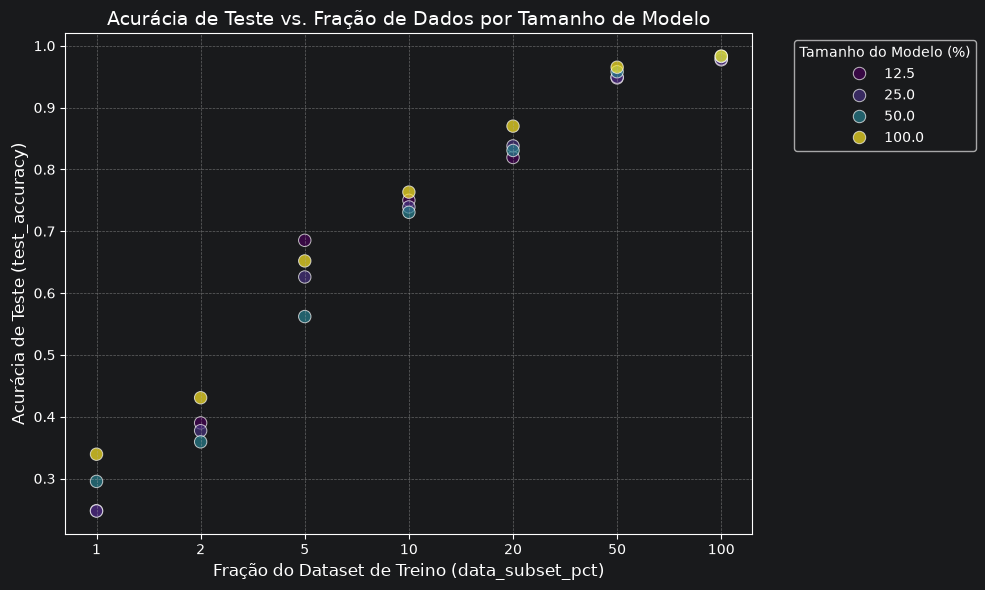

In [12]:
plt.figure(figsize=(10, 6))

dataframe['data_subset_pct_cat'] = pd.Categorical(
    dataframe['data_subset_pct'].astype(str),
    categories=[str(x) for x in sorted(dataframe['data_subset_pct'].unique())],
    ordered=True
)

sns.scatterplot(
    data=dataframe,
    x='data_subset_pct_cat',
    y='test_accuracy',
    hue='model_size_pct',
    palette='viridis',
    s=80,
    alpha=0.7
)

plt.title('Acurácia de Teste vs. Fração de Dados por Tamanho de Modelo', fontsize=14)
plt.xlabel('Fração do Dataset de Treino (data_subset_pct)', fontsize=12)
plt.ylabel('Acurácia de Teste (test_accuracy)', fontsize=12)
plt.legend(title='Tamanho do Modelo (%)', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


```
Comportamento da loss
```

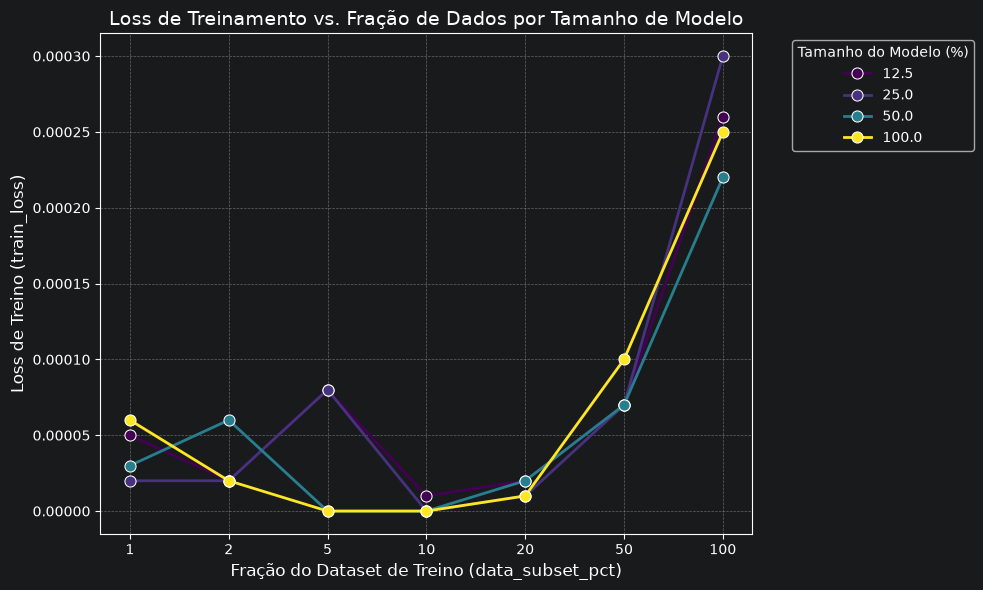

In [13]:
plt.figure(figsize=(10, 6))

dataframe['data_subset_pct_cat'] = pd.Categorical(
    dataframe['data_subset_pct'].astype(str),
    categories=[str(x) for x in sorted(dataframe['data_subset_pct'].unique())],
    ordered=True
)

sns.lineplot(
    data=dataframe,
    x='data_subset_pct_cat',
    y='train_loss',
    hue='model_size_pct',
    palette='viridis',
    linewidth=2,
    marker='o',
    markersize=8,
    errorbar=None
)

plt.title('Loss de Treinamento vs. Fração de Dados por Tamanho de Modelo', fontsize=14)
plt.xlabel('Fração do Dataset de Treino (data_subset_pct)', fontsize=12)
plt.ylabel('Loss de Treino (train_loss)', fontsize=12)
plt.legend(title='Tamanho do Modelo (%)', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [14]:
def scaling_law(x, a, b, c):
    # a * x^(-b) + c
    return a * np.power(x, -b) + c

def avaliar_scaling_law(df, nome_dataset):
    print(f"--- Avaliando Dataset: {nome_dataset} ---")

    df = df.copy()
    if 'test_error_rate' not in df.columns:
        df['test_error_rate'] = 1.0 - df['test_accuracy']

    df_train = df[df['data_subset_pct'] <= 50]
    df_test = df[df['data_subset_pct'] == 100]

    X_train = df_train['data_subset_pct'].values
    y_train_error = df_train['test_error_rate'].values

    X_test = df_test['data_subset_pct'].values
    y_test_real_acc = df_test['test_accuracy'].values

    try:
        popt, pcov = curve_fit(scaling_law, X_train, y_train_error, p0=[1.0, 0.5, 0.0], maxfev=10000)
        a_opt, b_opt, c_opt = popt

        print(f"Parâmetros encontrados: a={a_opt:.4f}, b={b_opt:.4f}, c={c_opt:.4f}")

        y_pred_error = scaling_law(X_test, a_opt, b_opt, c_opt)
        y_pred_acc = 1.0 - y_pred_error

        # 5. Comparar Previsto vs Real
        for i in range(len(X_test)):
            print(f"Volume Real: {X_test[i]}%")
            print(f"  -> Acurácia Real....: {y_test_real_acc[i]:.4f}")
            print(f"  -> Acurácia Prevista: {y_pred_acc[i]:.4f}")
            print(f"  -> Diferença (Erro).: {abs(y_test_real_acc[i] - y_pred_acc[i]):.4f}\n")

    except RuntimeError as e:
        print(f"O algoritmo não conseguiu convergir para {nome_dataset}: {e}\n")

In [16]:
avaliar_scaling_law(dataframe, "mean_model (Apenas um ponto por subset)")


--- Avaliando Dataset: mean_model (Apenas um ponto por subset) ---
Parâmetros encontrados: a=1.3308, b=0.1894, c=-0.5953
Volume Real: 100%
  -> Acurácia Real....: 0.9773
  -> Acurácia Prevista: 1.0390
  -> Diferença (Erro).: 0.0617

Volume Real: 100%
  -> Acurácia Real....: 0.9787
  -> Acurácia Prevista: 1.0390
  -> Diferença (Erro).: 0.0603

Volume Real: 100%
  -> Acurácia Real....: 0.9827
  -> Acurácia Prevista: 1.0390
  -> Diferença (Erro).: 0.0563

Volume Real: 100%
  -> Acurácia Real....: 0.9833
  -> Acurácia Prevista: 1.0390
  -> Diferença (Erro).: 0.0557



In [17]:
def plotar_curva_escala(df, nome_dataset):
    df = df.copy()

    # Garantir que temos a taxa de erro para o ajuste matemático
    if 'test_error_rate' not in df.columns:
        df['test_error_rate'] = 1.0 - df['test_accuracy']

    # Separar os dados de Treino (<= 50%) e Validação (== 100%)
    df_train = df[df['data_subset_pct'] <= 50]
    df_test = df[df['data_subset_pct'] == 100]

    X_train = df_train['data_subset_pct'].values
    y_train_error = df_train['test_error_rate'].values
    y_train_acc = df_train['test_accuracy'].values

    X_test = df_test['data_subset_pct'].values
    y_test_acc = df_test['test_accuracy'].values

    try:
        popt, _ = curve_fit(scaling_law, X_train, y_train_error, p0=[1.0, 0.5, 0.0], maxfev=10000)
        a_opt, b_opt, c_opt = popt
        X_line = np.linspace(1, 100, 500)
        Y_line_acc = 1.0 - scaling_law(X_line, a_opt, b_opt, c_opt)

        pred_100_acc = 1.0 - scaling_law(100, a_opt, b_opt, c_opt)

        plt.figure(figsize=(10, 6))
        plt.plot(X_line, Y_line_acc, color='#1f77b4', linestyle='--', linewidth=2, label='Curva de Regressão (Power Law)')
        plt.scatter(X_train, y_train_acc, color='#2ca02c', s=60, zorder=5, label='Dados de Treino (≤ 50%)')
        plt.scatter(X_test, y_test_acc, color='#d62728', marker='s', s=80, zorder=5, label='Valor Real (100%)')
        plt.scatter(100, pred_100_acc, color='#ff7f0e', marker='X', s=150, zorder=6, label=f'Previsão para 100% ({pred_100_acc:.4f})')
        plt.title(f'Scaling Law - Ajuste e Previsão\nDataset: {nome_dataset}', fontsize=14, fontweight='bold')
        plt.xlabel('Volume de Dados (data_subset_pct %)', fontsize=12)
        plt.ylabel('Métrica de Desempenho (test_accuracy)', fontsize=12)
        plt.xticks([1, 2, 5, 10, 20, 50, 100])
        plt.grid(True, linestyle=':', alpha=0.6)
        plt.legend(loc='lower right', fontsize=10)

        plt.tight_layout()
        plt.show()

    except RuntimeError as e:
        print(f"Não foi possível gerar o gráfico para {nome_dataset}: {e}")

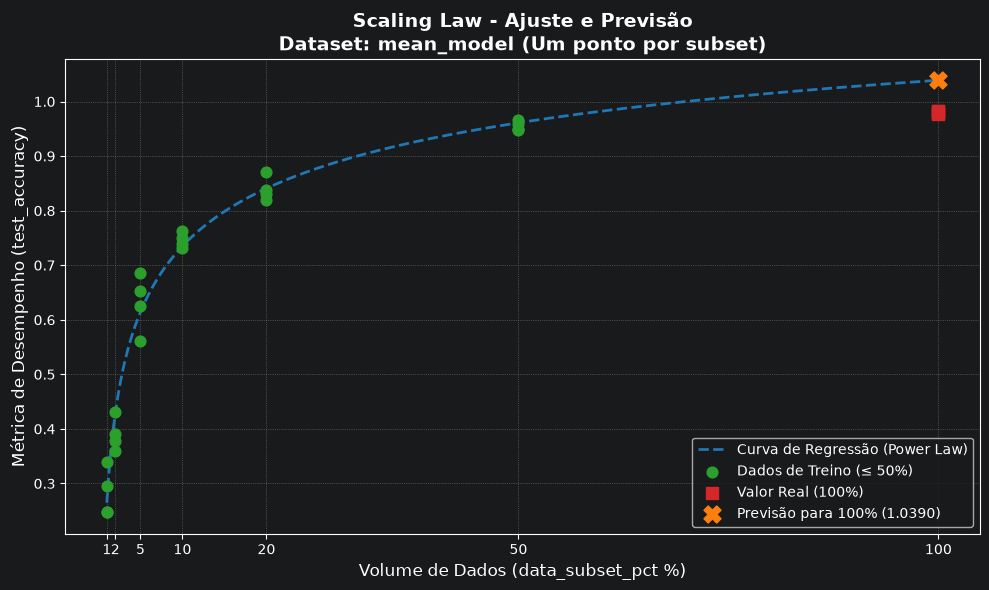

In [18]:
plotar_curva_escala(dataframe, "mean_model (Um ponto por subset)")


## Validação

## conclusão

A conclusão revisitará a questão de pesquisa à luz da superfície conjunta de resultados, verificando
se a relação entre erro de generalização, capacidade do modelo e volume de dados observada
experimentalmente é consistente com a forma funcional proposta na literatura de escalonamento
conjunto, ou se desvios sistemáticos emergem — por exemplo, nos pontos de menor capacidade e
maior volume de dados, onde a capacidade representacional pode se tornar o fator limitante antes
da exaustão dos dados disponíveis.
Referência: Rosenfeld, Rosenfeld, Belinkov & Shavit (2020) — A Constructive Prediction of the Generalization Error
Across Scales, ICLR.

Por fim, será discutida a relação de custo-benefício entre as duas dimensões de escalonamento —
tempo de anotação e coleta de dados versus custo computacional de treinar um modelo maior —
em uma lógica adaptada da alocação ótima de computação entre tamanho de modelo e volume de
dados, originalmente formulada para modelos de linguagem e aqui transposta ao contexto de visão
computacional.